In [1]:
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q ftfy regex tqdm
!pip install -q scikit-learn scipy matplotlib torchvision

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00


In [2]:
import os
import random

import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Subset

import clip

from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## PART 1: Zero Shot classification on STL-10

In [4]:
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [5]:
MODEL_NAME = "ViT-B/32"

model, preprocess = clip.load(MODEL_NAME, device=device)
model.eval()

print(f"Loaded CLIP model: {MODEL_NAME}")
print(f"Input resolution: {model.visual.input_resolution}")
print(f"Context length: {model.context_length}")
print(f"Vocab size: {model.vocab_size}")

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 152MiB/s]


Loaded CLIP model: ViT-B/32
Input resolution: 224
Context length: 77
Vocab size: 49408


In [6]:
data_dir = "./data"

stl10_test_data = torchvision.datasets.STL10(
    root=data_dir,
    split="test",
    download=True,
    transform=preprocess,
)

class_names = stl10_test_data.classes
print(f"Number of test images: {len(stl10_test_data)}")
print(f"Classes ({len(class_names)}): {class_names}")

100%|██████████| 2.64G/2.64G [08:59<00:00, 4.90MB/s] 


Number of test images: 8000
Classes (10): ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [7]:
transport_classes = ["airplane", "car", "ship", "truck"]

def find_article(word):
    first_char = word[0].lower()
    if first_char in ["a", "e", "i", "o", "u"]:
        return "an"
    else:
        return "a"

def single_word(item):
    return item

def standard_phrase(item):
    return f"a clear picture of {find_article(item)} {item}."

def detailed_description(item):
    if item in transport_classes:
        category = "transportation"
    else:
        category = "living creature"
    return f"a clear picture of {find_article(item)} {item}, which is a type of {category}, outdoors."

prompt_styles = {
    "Single word only": single_word,
    "Standard template": standard_phrase,
    "Detailed context": detailed_description,
}

for desc, function in prompt_styles.items():
    example_text = function(class_names[3])
    print(f"{desc:35s} -> {example_text!r}")

Single word only                    -> 'cat'
Standard template                   -> 'a clear picture of a cat.'
Detailed context                    -> 'a clear picture of a cat, which is a type of living creature, outdoors.'


In [8]:
def get_text_features(classes, prompt_function, clip_model, current_device):
    text_list = []
    for c in classes:
        text_list.append(prompt_function(c))
        
    tokens = clip.tokenize(text_list).to(current_device)
    
    with torch.no_grad():
        features = clip_model.encode_text(tokens).float()
        
    norm_features = features / features.norm(dim=-1, keepdim=True)
    return norm_features

def check_accuracy(clip_model, data_loader, txt_features, current_device):
    num_correct = 0
    num_total = 0
    
    with torch.no_grad():
        for imgs, tgts in data_loader:
            imgs = imgs.to(current_device)
            tgts = tgts.to(current_device)

            img_feats = clip_model.encode_image(imgs).float()
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

            similarity = 100.0 * img_feats @ txt_features.T
            predictions = similarity.argmax(dim=-1)

            for i in range(len(predictions)):
                if predictions[i] == tgts[i]:
                    num_correct += 1
                num_total += 1

    return num_correct / num_total

In [9]:
#sanity check on smaller dataset
subset_size = 200
indices = list(range(len(stl10_test_data)))
random.shuffle(indices)
chosen_indices = indices[:subset_size]

small_dataset = Subset(stl10_test_data, chosen_indices)
small_loader = DataLoader(small_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Trying {len(prompt_styles)} prompt strategies on a {subset_size}-image subset...\n")

for p_name, p_func in prompt_styles.items():
    t_feats = get_text_features(class_names, p_func, model, device)
    accuracy = check_accuracy(model, small_loader, t_feats, device)
    print(f"{p_name:35s} subset accuracy: {accuracy*100:5.2f}%")

Trying 3 prompt strategies on a 200-image subset...

Single word only                    subset accuracy: 96.50%
Standard template                   subset accuracy: 97.00%
Detailed context                    subset accuracy: 98.00%


In [10]:
#full test run
big_loader = DataLoader(stl10_test_data, batch_size=256, shuffle=False, num_workers=2)
accuracy_results = {}

for p_name, p_func in prompt_styles.items():
    t_feats = get_text_features(class_names, p_func, model, device)
    accuracy = check_accuracy(model, big_loader, t_feats, device)
    accuracy_results[p_name] = accuracy
    print(f"{p_name:35s} full test accuracy: {accuracy*100:5.2f}%")

Single word only                    full test accuracy: 96.25%
Standard template                   full test accuracy: 96.39%
Detailed context                    full test accuracy: 96.91%


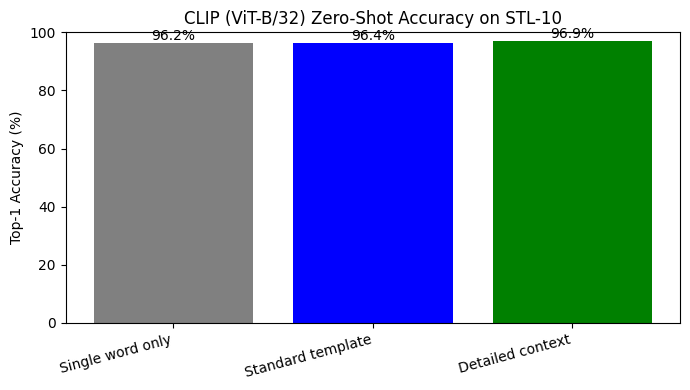

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

strat_names = list(accuracy_results.keys())
strat_accs = []
for n in strat_names:
    strat_accs.append(accuracy_results[n] * 100)
    
bar_colors = ["gray", "blue", "green"]
my_bars = ax.bar(strat_names, strat_accs, color=bar_colors)

ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title(f"CLIP ({MODEL_NAME}) Zero-Shot Accuracy on STL-10")
ax.set_ylim(0, 100)

for i in range(len(my_bars)):
    b = my_bars[i]
    val = strat_accs[i]
    ax.text(b.get_x() + b.get_width() / 2, val + 1, f"{val:.1f}%", ha="center")
    
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## PART 2: Exploring the Modality Gap

In [15]:
num_samples = 100

all_indices = list(range(len(stl10_test_data)))
random.shuffle(all_indices)
selected_inds = all_indices[:num_samples]

imgs_list = []
lbls_list = []

for i in selected_inds:
    img, lbl = stl10_test_data[i]
    imgs_list.append(img)
    lbls_list.append(lbl)

stacked_images = torch.stack(imgs_list).to(device)
labels_arr = np.array(lbls_list)

text_sentences = []
for l in labels_arr:
    c_name = class_names[l]
    text_sentences.append(standard_phrase(c_name))    
tokenized_txt = clip.tokenize(text_sentences).to(device)

with torch.no_grad():
    img_embeds = model.encode_image(stacked_images).float()
    txt_embeds = model.encode_text(tokenized_txt).float()

print("image_embeddings:", img_embeds.shape)
print("text_embeddings :", txt_embeds.shape)

image_embeddings: torch.Size([100, 512])
text_embeddings : torch.Size([100, 512])


In [16]:
def do_tsne(data_array, perp=30, s=SEED):
    row_count = data_array.shape[0]
    max_perp = row_count // 4
    if perp > max_perp:
        perp = max_perp
    if perp < 5:
        perp = 5
        
    tsne_model = TSNE(
        n_components=2,
        perplexity=perp,
        init="pca",
        learning_rate="auto",
        random_state=s,
    )
    return tsne_model.fit_transform(data_array)

def draw_gap(coords, num_imgs, classes_arr, all_class_names, chart_title):
    img_pts = coords[:num_imgs]
    txt_pts = coords[num_imgs:]

    fig, ax = plt.subplots(figsize=(7, 6))
    color_map = cm.tab10(np.linspace(0, 1, 10))

    unique_c = np.unique(classes_arr)
    for c in unique_c:
        c_mask = (classes_arr == c)
        ax.scatter(img_pts[c_mask, 0], img_pts[c_mask, 1],
                   color=color_map[c], marker="o", s=35, alpha=0.8)
        ax.scatter(txt_pts[c_mask, 0], txt_pts[c_mask, 1],
                   color=color_map[c], marker="^", s=120,
                   edgecolor="black", linewidth=0.6, alpha=0.9)

    item1 = Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="Image")
    item2 = Line2D([0], [0], marker="^", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=10, label="Text")
    
    ax.legend(handles=[item1, item2], loc="best")
    ax.set_title(chart_title)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    plt.tight_layout()
    plt.show()

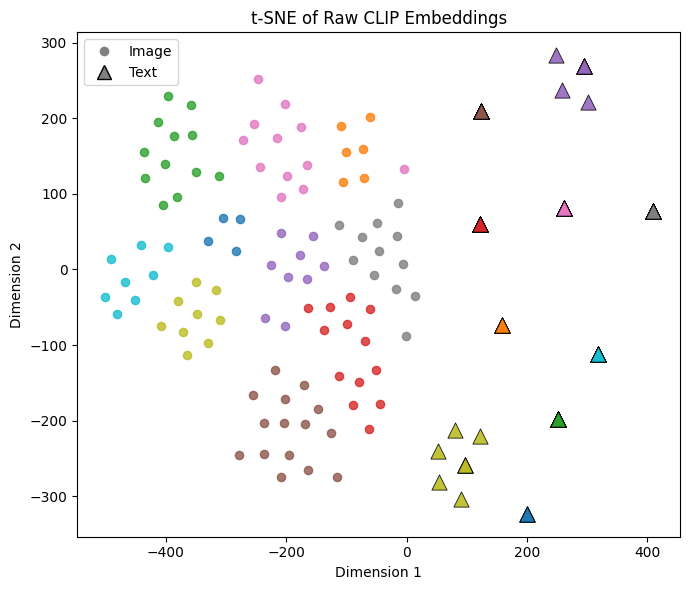

In [17]:
joined_raw = torch.cat([img_embeds, txt_embeds], dim=0)
joined_raw_np = joined_raw.cpu().numpy()

pts_raw = do_tsne(joined_raw_np, perp=30)

draw_gap(
    pts_raw, num_samples, labels_arr, class_names,
    chart_title="t-SNE of Raw CLIP Embeddings",
)

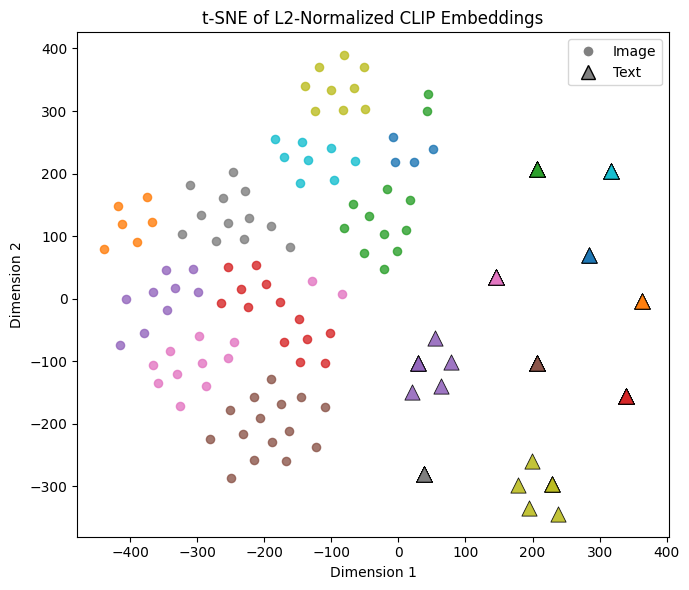

In [18]:
#L2 normalization
img_embeds_n = F.normalize(img_embeds, dim=-1)
txt_embeds_n = F.normalize(txt_embeds, dim=-1)

joined_norm = torch.cat([img_embeds_n, txt_embeds_n], dim=0)
joined_norm_np = joined_norm.cpu().numpy()

pts_norm = do_tsne(joined_norm_np, perp=30)

draw_gap(
    pts_norm, num_samples, labels_arr, class_names,
    chart_title="t-SNE of L2-Normalized CLIP Embeddings",
)

In [19]:
def get_gap_stats(img_e, txt_e):
    c_img = img_e.mean(dim=0)
    c_txt = txt_e.mean(dim=0)
    dist = (c_img - c_txt).norm().item()

    i_norm = F.normalize(img_e, dim=-1)
    t_norm = F.normalize(txt_e, dim=-1)

    w_img = (i_norm @ i_norm.T).mean().item()
    w_txt = (t_norm @ t_norm.T).mean().item()
    cross_all = (i_norm @ t_norm.T).mean().item()
    
    cross_match_sum = 0
    for k in range(i_norm.shape[0]):
        cross_match_sum += torch.dot(i_norm[k], t_norm[k]).item()
    cross_match = cross_match_sum / i_norm.shape[0]

    return {
        "Distance between centers": dist,
        "Image-Image similarity": w_img,
        "Text-Text similarity": w_txt,
        "Image-Text similarity (all)": cross_all,
        "Image-Text similarity (matched)": cross_match,
    }

print("Raw Embeddings:")
raw_stats = get_gap_stats(img_embeds, txt_embeds)
for key in raw_stats:
    print(f"  {key:35s}: {raw_stats[key]:.4f}")

print("\nNormalized Embeddings:")
norm_stats = get_gap_stats(img_embeds_n, txt_embeds_n)
for key in norm_stats:
    print(f"  {key:35s}: {norm_stats[key]:.4f}")

Raw Embeddings:
  Distance between centers           : 10.8209
  Image-Image similarity             : 0.6205
  Text-Text similarity               : 0.8730
  Image-Text similarity (all)        : 0.1881
  Image-Text similarity (matched)    : 0.2523

Normalized Embeddings:
  Distance between centers           : 1.0570
  Image-Image similarity             : 0.6205
  Text-Text similarity               : 0.8730
  Image-Text similarity (all)        : 0.1881
  Image-Text similarity (matched)    : 0.2523


## PART 3: Briding the Modality Gap

In [20]:
x_mat = img_embeds_n.detach().cpu().numpy().astype(np.float64)
y_mat = txt_embeds_n.detach().cpu().numpy().astype(np.float64)

rotation_matrix, scale_val = orthogonal_procrustes(x_mat, y_mat)

print("Rotation matrix shape:", rotation_matrix.shape)

ident_check = rotation_matrix.T @ rotation_matrix - np.eye(rotation_matrix.shape[0])
error_norm = np.linalg.norm(ident_check)
print(f"Orthogonality check error: {error_norm:.2e}")
print(f"Scale value: {scale_val:.4f}")

Rotation matrix shape: (512, 512)
Orthogonality check error: 4.65e-14
Scale value: 87.2727


In [21]:
rot_torch = torch.from_numpy(rotation_matrix).float().to(device)

aligned_imgs = img_embeds_n @ rot_torch
aligned_imgs = F.normalize(aligned_imgs, dim=-1)

print("Aligned images shape:", aligned_imgs.shape)

Aligned images shape: torch.Size([100, 512])


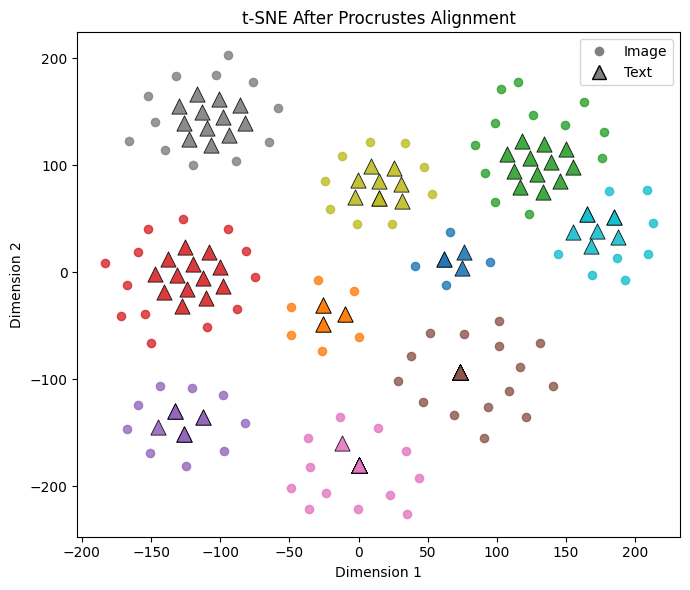

Stats after alignment:
  Distance between centers           : 0.1469
  Image-Image similarity             : 0.6205
  Text-Text similarity               : 0.8730
  Image-Text similarity (all)        : 0.7360
  Image-Text similarity (matched)    : 0.8727


In [22]:
joined_aligned = torch.cat([aligned_imgs, txt_embeds_n], dim=0).cpu().numpy()
pts_aligned = do_tsne(joined_aligned, perp=30)

draw_gap(
    pts_aligned, num_samples, labels_arr, class_names,
    chart_title="t-SNE After Procrustes Alignment",
)

print("Stats after alignment:")
aligned_stats = get_gap_stats(aligned_imgs, txt_embeds_n)
for key in aligned_stats:
    print(f"  {key:35s}: {aligned_stats[key]:.4f}")

In [24]:
def check_accuracy_rotated(clip_model, data_loader, txt_features, rot_mat, current_device):
    num_correct = 0
    num_total = 0
    
    with torch.no_grad():
        for imgs, tgts in data_loader:
            imgs = imgs.to(current_device)
            tgts = tgts.to(current_device)

            i_feats = clip_model.encode_image(imgs).float()
            i_feats = F.normalize(i_feats, dim=-1)
            
            i_feats = i_feats @ rot_mat
            i_feats = F.normalize(i_feats, dim=-1)

            sim = 100.0 * i_feats @ txt_features.T
            preds = sim.argmax(dim=-1)

            for i in range(len(preds)):
                if preds[i] == tgts[i]:
                    num_correct += 1
                num_total += 1

    return num_correct / num_total

base_t_feats = get_text_features(class_names, standard_phrase, model, device)

acc_first = accuracy_results["Standard template"]
acc_second = check_accuracy_rotated(model, big_loader, base_t_feats, rot_torch, device)

print(f"Accuracy BEFORE alignment: {acc_first*100:5.2f}%")
print(f"Accuracy AFTER alignment: {acc_second*100:5.2f}%")

diff = (acc_second - acc_first) * 100
if diff >= 0:
    print(f"Change: +{diff:.2f}%")
else:
    print(f"Change: {diff:.2f}%")

Accuracy BEFORE alignment: 96.39%
Accuracy AFTER alignment: 96.09%
Change: -0.30%


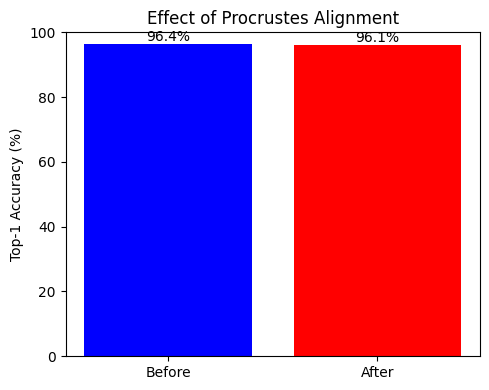

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))

x_labels = ["Before", "After"]
y_vals = [acc_first * 100, acc_second * 100]

b_plot = ax.bar(x_labels, y_vals, color=["blue", "red"])

ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Effect of Procrustes Alignment")
ax.set_ylim(0, 100)

for i in range(len(b_plot)):
    bar_obj = b_plot[i]
    v = y_vals[i]
    ax.text(bar_obj.get_x() + bar_obj.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
    
plt.tight_layout()
plt.show()